In [84]:
import os

import numpy as np
import torch
import torch.nn as nn
import wfdb.processing
import torch.nn.functional as F
from tqdm import tqdm
import keras
import tensorflow as tf
import scipy
import time
from tqdm import tqdm

### Miejsce na model

In [85]:
class SimpleConv(nn.Module):
    def __init__(self, input_size=40, input_ch=1, num_classes=2):
        super(SimpleConv, self).__init__()

        # Uproszczona wersja modelu
        self.conv1 = nn.Conv1d(input_ch, 64, kernel_size=5, padding='same')
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding='same')
        self.bn2 = nn.BatchNorm1d(128)
        self.pool = nn.MaxPool1d(2)

        # Obliczymy wymiar po warstwach Conv1d i MaxPool1d
        self.fc1_input_size = 128 * (input_size // 2)  # Po 2 max pooling
        self.fc1 = nn.Linear(self.fc1_input_size, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Pass through conv1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)

        # Pass through conv2
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)

        # Max pooling
        x = self.pool(x)

        # Flatten the output for the fully connected layers
        x = torch.flatten(x, 1)

        # Fully connected layers
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

### Evaluacja

In [86]:
def bce_dice_weighted_loss_wrapper(bce_w, dice_w, smooth=10e-6):
    bce_loss = keras.losses.BinaryCrossentropy()
    dice_loss = dice_coef_loss_wrapper(smooth)
    def bce_dice_weighted_loss(y_true, y_pred):
        return bce_w * bce_loss(y_true, y_pred) + dice_w * dice_loss(y_true, y_pred)
    return bce_dice_weighted_loss

def dice_coef_wrapper(smooth=10e-6):
    def dice_coef(y_true, y_pred):
        y_true_f = y_true
        y_pred_f = y_pred
        intersection = tf.reduce_sum(y_true_f * y_pred_f)
        dice = (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)
        return dice
    return dice_coef


def dice_coef_loss_wrapper(smooth=10e-6):
    dice_coef = dice_coef_wrapper(smooth)
    def dice_coef_loss(y_true, y_pred):
        return 1 - dice_coef(y_true, y_pred)
    return dice_coef_loss


In [87]:
import os

import numpy as np
import torch
import torch.nn as nn
import wfdb.processing
import torch.nn.functional as F
from tqdm import tqdm
import keras
import tensorflow as tf
import scipy
import time
import torch
import torch.nn as nn
import torch.nn.functional as F


class RecordEvaluator:
    def __init__(self, dest_dir):
        self._dest_dir = dest_dir
        self._model = SimpleConv()
        self._model.load_state_dict(torch.load("simp_conv_qrs.pt", weights_only=True))
        self._model.eval()
        self.iteration = 0

    def evaluate(self, signal_reader):
        signal = signal_reader.read_signal()[:,0]
        fs = signal_reader.read_fs()
        # if self.iteration != 0:
        #     pred = np.ones([len(signal), ], dtype=np.float32)
        #     code = signal_reader.get_code()
        #     np.save(os.path.join(self._dest_dir, f'{code}'), pred)
        #     return
        self.iteration += 1
        # fs_conv = 100
        # num_samples_target = int(len(signal) * fs_conv / fs)
        # resampled_signal = scipy.signal.resample(signal, num_samples_target)
        xqrs = wfdb.processing.XQRS(sig=signal, fs=fs)
        xqrs.detect()
        qrs_inds = xqrs.qrs_inds
        print(len(qrs_inds))
        rr = wfdb.processing.calc_rr(qrs_inds, fs=fs, min_rr=None, max_rr=None, qrs_units='samples',
                                     rr_units='seconds')
        input_rr_samples = 40
        batch_size = 64
        pred = np.zeros([len(signal), ], dtype=np.float32)
        
        # resampled_labels = np.zeros(len(rr))

        for idx in range(20, len(rr) - 20, 40):
            input = np.array([rr[idx-20:idx+20]])
            input = torch.Tensor(input).unsqueeze(0)
            outputs = self._model.forward(input)
            
            _, predicted = torch.max(outputs.data, 1)
            print(outputs.data)
            pred[qrs_inds[idx-20]:qrs_inds[idx+20]] = predicted.numpy()

        
        # # for i in range(len(pred)):
        # #     pred[i] = resampled_labels[int(i * fs_conv / fs)]
        # # endtime = time.time()
        # for i in range(len(pred)):
        #     index = int(i * fs_conv / fs)
        #     if index < len(resampled_labels):  # Sprawdź, czy indeks mieści się w granicach
        #         pred[i] = int(resampled_labels[index])
        #     else:
        #         pred[i] = 0  # Możesz ustawić domyślną wartość, np. 0

        return pred
        # code = signal_reader.get_code()
        # np.save(os.path.join(self._dest_dir, f'{code}'), pred)


In [88]:
class SignalReader:
    def __init__(self, name, dataset_dir = 'c:/D/DNN/dnn_ecg_main/Datasets/files/'):
        self.record = wfdb.rdsamp(f"{dataset_dir}{name}") 
        self.annotation = wfdb.rdann(f"{dataset_dir}{name}", 'atr')
        self.signal = self.record[0]
        self.gt = np.zeros([len(self.signal), ], dtype=np.float32)


        if(len(self.annotation.sample)==1):
            idx_next = len(self.signal)
        else:
            idx_next = self.annotation.sample[1]
        label_t = self.annotation.aux_note[0]
        temp_aux = 0
        for idx in range(self.annotation.sample[0],len(self.signal)):
            while(idx>=idx_next):
                temp_aux += 1
                if(temp_aux!=len(self.annotation.sample)-1):
                    idx_next = self.annotation.sample[temp_aux+1]
                else:
                    idx_next = len(self.signal)
                label_t = self.annotation.aux_note[temp_aux]
            if(label_t == '(AFIB'):
                self.gt[idx] = 1
            else:
                self.gt[idx] = 0

    
    def read_signal(self):
        return self.signal

    def read_fs(self):
        return self.record[1]["fs"]

In [89]:

record_eval = RecordEvaluator('./')
signal_reader = SignalReader('06995')
seg = record_eval.evaluate(signal_reader)
gt = signal_reader.gt


Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
56634
tensor([[-0.5247,  0.5246]])
tensor([[-1.2521,  1.2521]])
tensor([[-0.0697,  0.0697]])
tensor([[ 0.5368, -0.5368]])
tensor([[-2.1006,  2.1006]])
tensor([[-0.5857,  0.5857]])
tensor([[-1.0663,  1.0662]])
tensor([[-1.9327,  1.9327]])
tensor([[-1.7796,  1.7796]])
tensor([[-0.9138,  0.9138]])
tensor([[-2.1457,  2.1457]])
tensor([[ 0.0667, -0.0667]])
tensor([[ 0.0858, -0.0858]])
tensor([[-2.2984,  2.2984]])
tensor([[-4.0820,  4.0820]])
tensor([[-1.6700,  1.6700]])
tensor([[ 0.2753, -0.2753]])
tensor([[-3.1838,  3.1838]])
tensor([[-1.3400,  1.3400]])
tensor([[-1.1124,  1.1124]])
tensor([[-2.6325,  2.6325]])
tensor([[-2.1208,  2.1208]])
tensor([[-1.3389,  1.3389]])
tensor([[-0.0616,  0.0616]])
tensor([[-0.6547,  0.6547]])
tensor([[ 0.3894, -0.3894]])
tensor([[-1.4760,  1.4760]])
tensor([[-0.9824,  0.9824]])
tensor([[-1.8639,  1.8639]

In [90]:
print(max(gt))
print(signal_reader.annotation.sample)
print(signal_reader.annotation.aux_note)

1.0
[      7 1381607 1383575 1387965 1389204 1399238 1856046 1864114 3789346
 3793222 6274349]
['(AFIB', '(AFL', '(AFIB', '(AFL', '(AFIB', '(N', '(AFIB', '(N', '(AFIB', '(N', '(AFIB']


In [91]:
seg[gt==1]
np.sum(seg[gt==1]==1)*2.0
dice = np.sum(seg[gt==1]==1)*2.0 / (np.sum(seg[seg==1]==1) + np.sum(gt[gt==1]==1))

In [92]:
print(dice)

0.9279471241721741


In [93]:
print(len(seg))

9205760


In [94]:
print(len(gt))

9205760


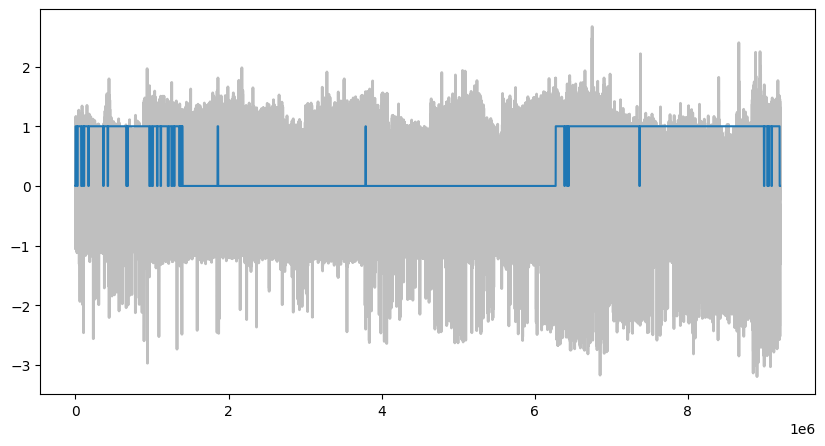

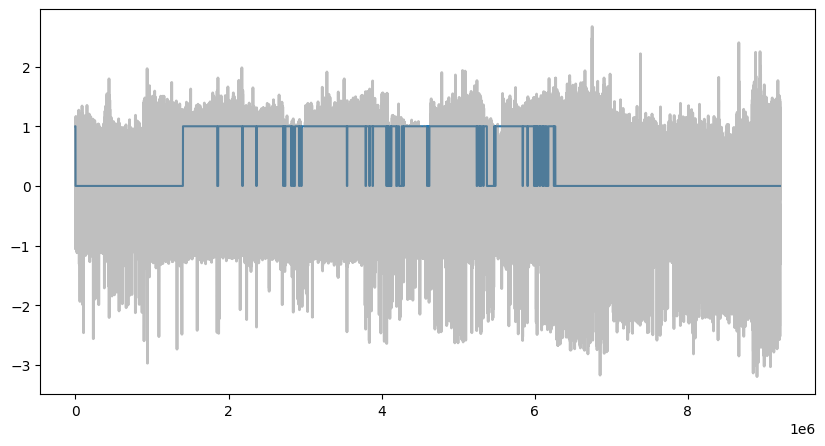

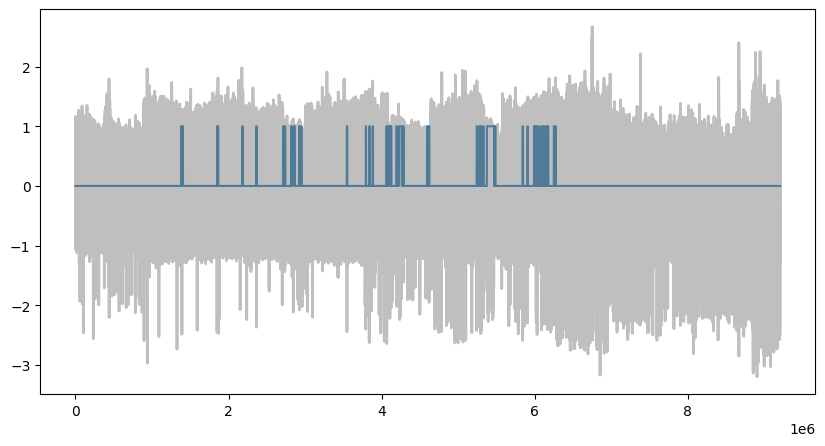

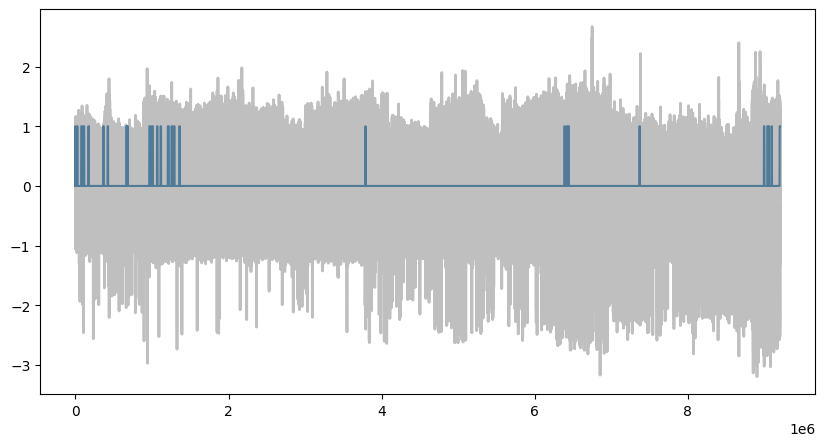

In [95]:
import numpy as np
import matplotlib.pyplot as plt
pred = seg
background_signal = signal_reader.read_signal()[:, 0]
# Identify TP, FP, TN, FN
TP = (pred == 1) & (gt == 1)
FP = (pred == 1) & (gt == 0)
TN = (pred == 0) & (gt == 0)
FN = (pred == 0) & (gt == 1)

# Define color map for segments
color_map = {
    'TP': 'green',
    'FP': 'red',
    'TN': 'blue',
    'FN': 'yellow'
}
# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(range(len(background_signal)), background_signal, color='gray', label='Background Signal', linewidth=2, alpha=0.5)

# Highlight segments based on classification
plt.plot(TP)
plt.show()
plt.figure(figsize=(10, 5))
plt.plot(TN)
plt.plot(range(len(background_signal)), background_signal, color='gray', label='Background Signal', linewidth=2, alpha=0.5)
plt.show()
plt.figure(figsize=(10, 5))
plt.plot(FP)
plt.plot(range(len(background_signal)), background_signal, color='gray', label='Background Signal', linewidth=2, alpha=0.5)
plt.show()
plt.figure(figsize=(10, 5))
plt.plot(FN)
plt.plot(range(len(background_signal)), background_signal, color='gray', label='Background Signal', linewidth=2, alpha=0.5)
plt.show()



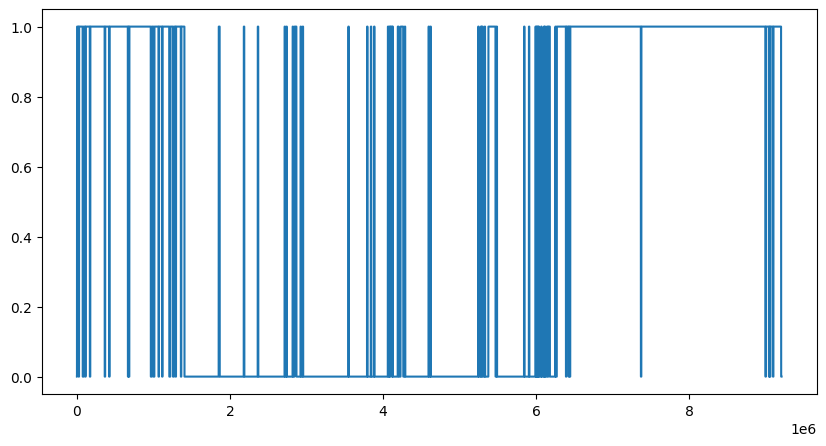

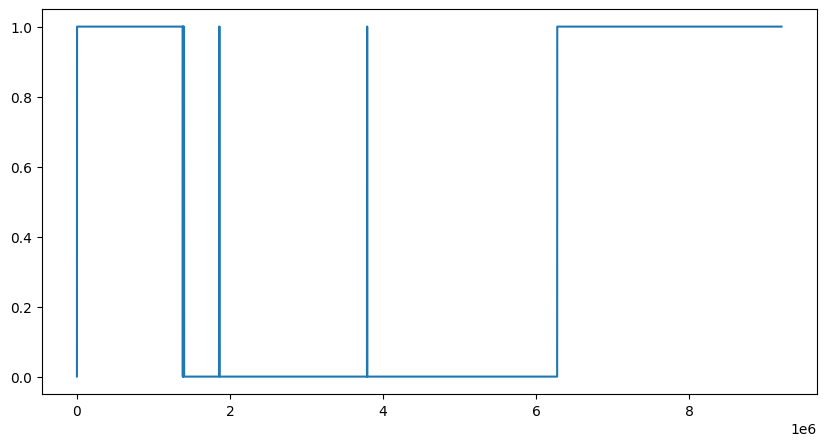

In [96]:

plt.figure(figsize=(10, 5))
plt.plot(pred)
plt.show()
plt.figure(figsize=(10, 5))
plt.plot(gt)
plt.show()

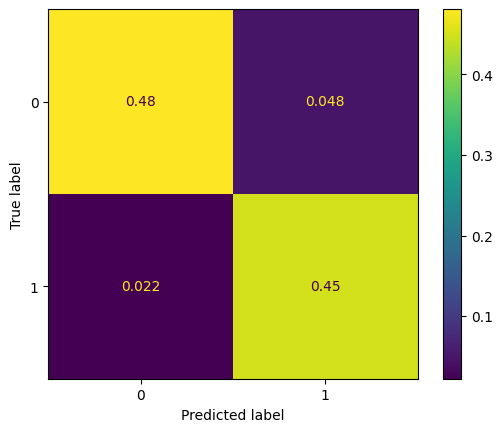

In [97]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
def normalize_confusion_matrix(cm, norm='true'):
    cm_normalized = cm.astype('float') / cm.sum()
    return cm_normalized
cm = confusion_matrix(gt, pred)
cm = normalize_confusion_matrix(cm, norm='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()